In [ ]:
import numpy as np 
import pandas as pd 


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import ExponentialLR

In [15]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Data paths
train_dir = r"C:\Users\madda\Downloads\NEU (DL)\NEU-DET\train\images"
val_dir   = r"C:\Users\madda\Downloads\NEU (DL)\NEU-DET\validation\images"


Using device: cpu


In [ ]:
import os
print(os.listdir(train_dir))
print(os.listdir(val_dir))


['annotations', 'images']
['annotations', 'images']


In [ ]:

train_transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


val_transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)


# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Number of classes
num_classes = 6

In [17]:
# Load pretrained EfficientNet-B0
base_model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Freeze the base model parameters
for param in base_model.parameters():
    param.requires_grad = False

# Modify the classifier to match our number of classes
base_model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features=1280, out_features=256),  # EfficientNet-B0 feature dimension is 1280
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=256, out_features=num_classes)
)

# Move model to device
model = base_model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\madda/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 42.9MB/s]


In [18]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
initial_learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=initial_learning_rate)

# Learning rate scheduler - exponential decay similar to the TF code
scheduler = ExponentialLR(optimizer, gamma=0.9) # gamma=0.9 is approximately equivalent to exp(-0.1)

In [19]:
# Training function
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        
        scheduler.step()
        
        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        
        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        
        # Validation phase
        model.eval()
        running_loss = 0.0
        running_corrects = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
        
        epoch_loss = running_loss / len(val_dataset)
        epoch_acc = running_corrects.double() / len(val_dataset)
        
        history['val_loss'].append(epoch_loss)
        history['val_acc'].append(epoch_acc.item())
        
        print(f'Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
    
    return history

In [20]:
# Print model summary 
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable parameters: {count_parameters(model)}")

Trainable parameters: 329478


In [21]:
# First training phase (base model frozen)
print("Training with frozen base model")
history_frozen = train_model(model, criterion, optimizer, scheduler, num_epochs=10)

Training with frozen base model
Epoch 1/10
----------
Train Loss: 0.6665 Acc: 0.7958
Val Loss: 0.2466 Acc: 0.9667
Epoch 2/10
----------
Train Loss: 0.2983 Acc: 0.9014
Val Loss: 0.2053 Acc: 0.9583
Epoch 3/10
----------
Train Loss: 0.2559 Acc: 0.9062
Val Loss: 0.1868 Acc: 0.9556
Epoch 4/10
----------
Train Loss: 0.2020 Acc: 0.9264
Val Loss: 0.1310 Acc: 0.9694
Epoch 5/10
----------
Train Loss: 0.1865 Acc: 0.9319
Val Loss: 0.1325 Acc: 0.9583
Epoch 6/10
----------
Train Loss: 0.1924 Acc: 0.9340
Val Loss: 0.1364 Acc: 0.9583
Epoch 7/10
----------
Train Loss: 0.1763 Acc: 0.9340
Val Loss: 0.1229 Acc: 0.9639
Epoch 8/10
----------
Train Loss: 0.1759 Acc: 0.9319
Val Loss: 0.1344 Acc: 0.9694
Epoch 9/10
----------
Train Loss: 0.1600 Acc: 0.9458
Val Loss: 0.1146 Acc: 0.9667
Epoch 10/10
----------
Train Loss: 0.1623 Acc: 0.9396
Val Loss: 0.1132 Acc: 0.9694


In [31]:
# First freeze all layers
for param in base_model.parameters():
    param.requires_grad = False

# Then unfreeze the last few blocks (features.7 and features.8 in EfficientNet-B0)
for name, param in base_model.named_parameters():
    if 'features.7' in name or 'features.8' in name or 'classifier' in name:
        param.requires_grad = True

In [32]:
# Update optimizer with lower learning rate
optimizer_fine_tune = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)
scheduler_fine_tune = ExponentialLR(optimizer_fine_tune, gamma=0.9)

In [33]:
# Continue training
history_fine_tune = train_model(model, criterion, optimizer_fine_tune, scheduler_fine_tune, num_epochs=15)

Epoch 1/15
----------
Train Loss: 0.0946 Acc: 0.9660
Val Loss: 0.0764 Acc: 0.9667
Epoch 2/15
----------
Train Loss: 0.1063 Acc: 0.9646
Val Loss: 0.0299 Acc: 0.9917
Epoch 3/15
----------
Train Loss: 0.0868 Acc: 0.9694
Val Loss: 0.0573 Acc: 0.9778
Epoch 4/15
----------
Train Loss: 0.0639 Acc: 0.9750
Val Loss: 0.0193 Acc: 1.0000
Epoch 5/15
----------
Train Loss: 0.0718 Acc: 0.9785
Val Loss: 0.0332 Acc: 0.9861
Epoch 6/15
----------
Train Loss: 0.0706 Acc: 0.9722
Val Loss: 0.0342 Acc: 0.9944
Epoch 7/15
----------
Train Loss: 0.0580 Acc: 0.9826
Val Loss: 0.0253 Acc: 0.9944
Epoch 8/15
----------
Train Loss: 0.0568 Acc: 0.9785
Val Loss: 0.0154 Acc: 1.0000
Epoch 9/15
----------
Train Loss: 0.0562 Acc: 0.9819
Val Loss: 0.0399 Acc: 0.9861
Epoch 10/15
----------
Train Loss: 0.0549 Acc: 0.9847
Val Loss: 0.0203 Acc: 0.9972
Epoch 11/15
----------
Train Loss: 0.0481 Acc: 0.9826
Val Loss: 0.0438 Acc: 0.9806
Epoch 12/15
----------
Train Loss: 0.0373 Acc: 0.9847
Val Loss: 0.0461 Acc: 0.9806
Epoch 13/15
-

In [34]:
history = {
    'train_loss': history_frozen['train_loss'] + history_fine_tune['train_loss'],
    'train_acc': history_frozen['train_acc'] + history_fine_tune['train_acc'],
    'val_loss': history_frozen['val_loss'] + history_fine_tune['val_loss'],
    'val_acc': history_frozen['val_acc'] + history_fine_tune['val_acc']
}

In [36]:
pip install seaborn


  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   -------------------------------------- - 286.7/294.9 kB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 3.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


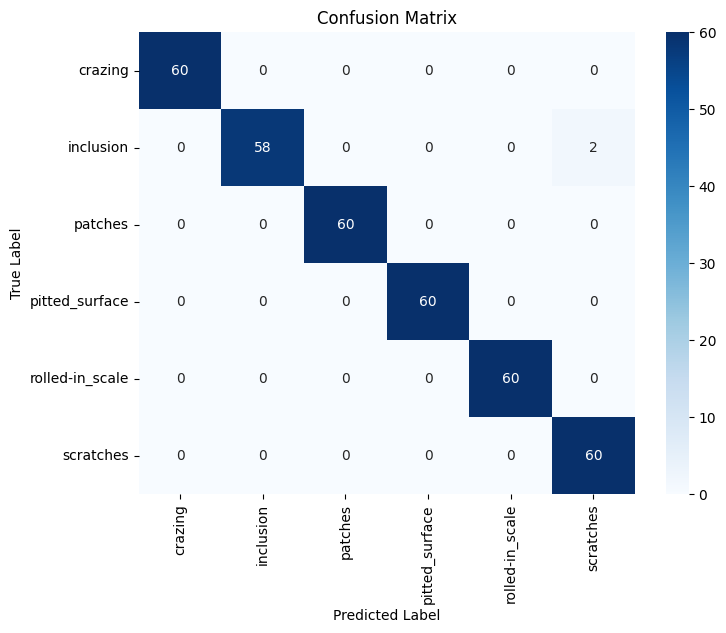

Classification Report:

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      0.97      0.98        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.97      1.00      0.98        60

       accuracy                           0.99       360
      macro avg       0.99      0.99      0.99       360
   weighted avg       0.99      0.99      0.99       360



In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns  # if not installed: pip install seaborn

# Put model in eval mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Get class names from dataset
class_names = train_dataset.classes

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


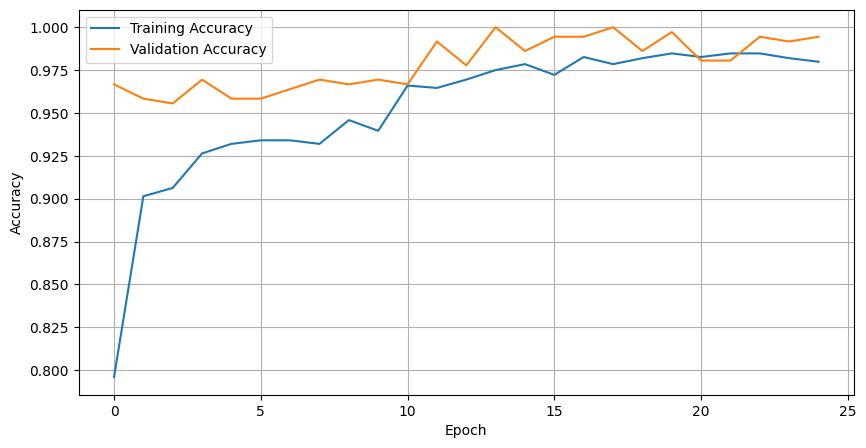

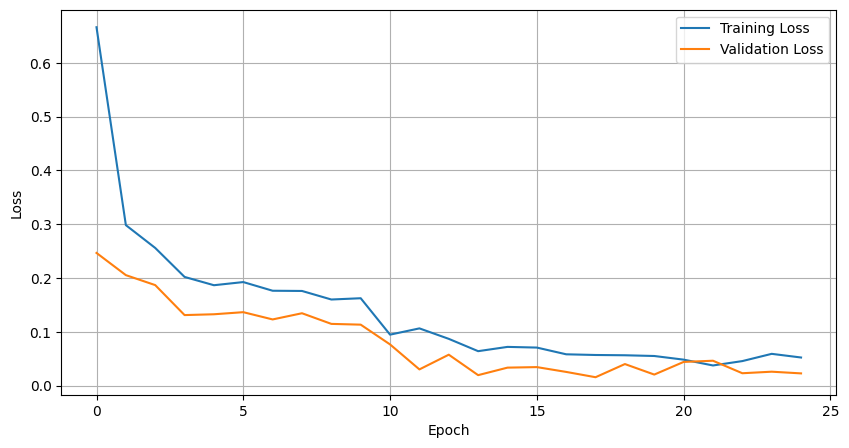

In [38]:
# Plot training and validation accuracy
def plot_history(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_acc'], label='Training Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot training and validation loss
def plot_loss_history(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the training history
plot_history(history)
plot_loss_history(history)

In [40]:
import pandas as pd

df = pd.DataFrame({
    "epoch": list(range(1, len(history["train_loss"]) + 1)),
    "train_loss": history["train_loss"],
    "train_acc": history["train_acc"],
    "val_loss": history["val_loss"],
    "val_acc": history["val_acc"],
})

df.to_csv("training_history.csv", index=False)
print("Saved training_history.csv")


Saved training_history.csv


In [41]:
import os
print(os.getcwd())


c:\Users\madda\Downloads\NEU-Surface-Defect-Classification-main\NEU-Surface-Defect-Classification-main\notebooks
